# 🧠🤖 第3周-Day1：预训练：数据、规模与涌现能力

今天我们进入大模型训练的核心内容！从Transformer架构学习到今天，终于要揭开"如何训练真正的大模型"的神秘面纱了～

## 🎯 学习目标

• 理解预训练的本质：让模型"读书识字"
• 掌握Scaling Laws：性能与规模的数学关系
• 认识涌现能力：模型突然获得的新技能
• 了解预训练数据的奥秘和要求

/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  fig.canvas.print_figure(bytes_io, **kw)
Font 'default' does not have a glyph for '1' [U+31], substituting with a dummy symbol.
Font 'default' does not have a glyph for '0' [U+30], substituting with a dummy symbol.
Font 'default' does not have a glyph for '7' [U+37], substituting with a dummy symbol.
Font 'default' does not have a glyph for 'x' [U+78], substituting with a dummy symbol.
Font 'default' does not have a glyph for '7' [U+37], substituting with a dummy symbol.
Font 'default' does not have a glyph for '1' [U+31], substituting with a dummy symbol.
Font 'default' does not have a glyph for '0' [U+30], substituting 

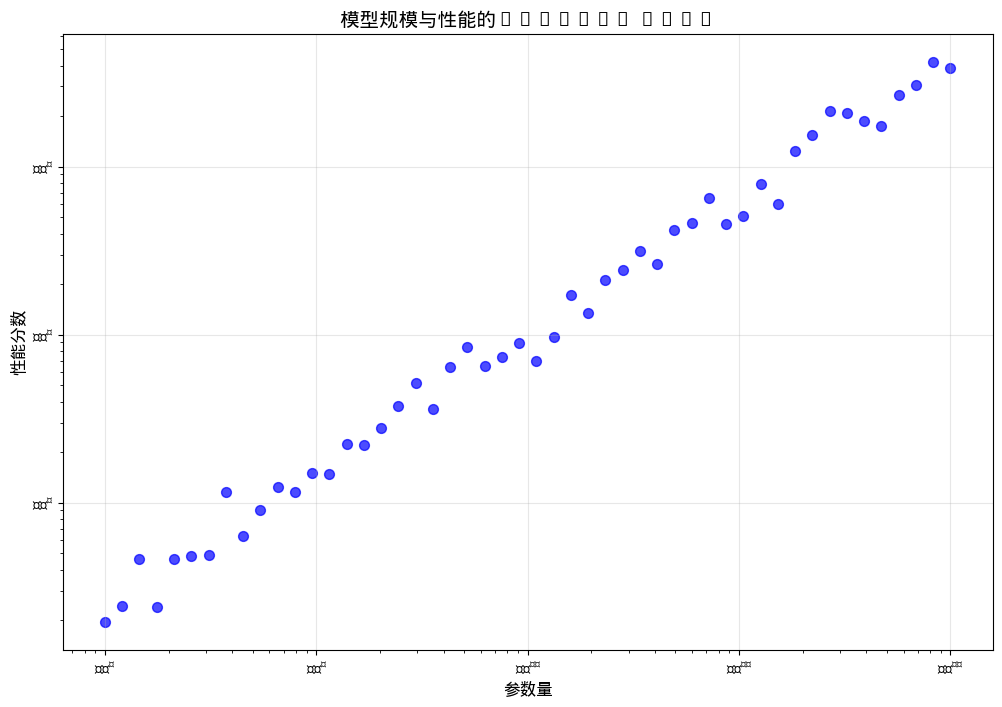

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'Droid Sans Fallback', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 模型规模vs性能的模拟数据
parameters = np.logspace(8, 12, 50)  # 1亿到1万亿参数
performance = np.log10(parameters) * 0.8 + np.random.normal(0, 0.1, len(parameters))

plt.figure(figsize=(12, 8))
plt.scatter(parameters, 10**performance, s=50, alpha=0.7, c='blue')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('参数量', fontsize=12)
plt.ylabel('性能分数', fontsize=12)
plt.title('模型规模与性能的Scaling Laws', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

## 📚 什么是预训练？

想象一个小孩子学说话👶：
• 读海量书籍、文章、对话（这就是预训练数据）
• 慢慢理解语法、词汇、语义规律
• 不需要专门教"什么是主谓宾"
• 通过大量阅读自然学会语言！

🤖 大模型的预训练也是一样，只不过"阅读"的是整个互联网的海量文本～

/tmp/ipykernel_285828/1413605723.py:23: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/1413605723.py:23: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/1413605723.py:23: UserWarning: Glyph 48 (0) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/1413605723.py:23: UserWarning: Glyph 50 (2) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/1413605723.py:23: UserWarning: Glyph 52 (4) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/1413605723.py:23: UserWarning: Glyph 54 (6) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/1413605723.py:23: UserWarning: Glyph 56 (8) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/1413605723.py:23: UserWarning: Glyph 49 (1) missing from font(s) Droid Sa

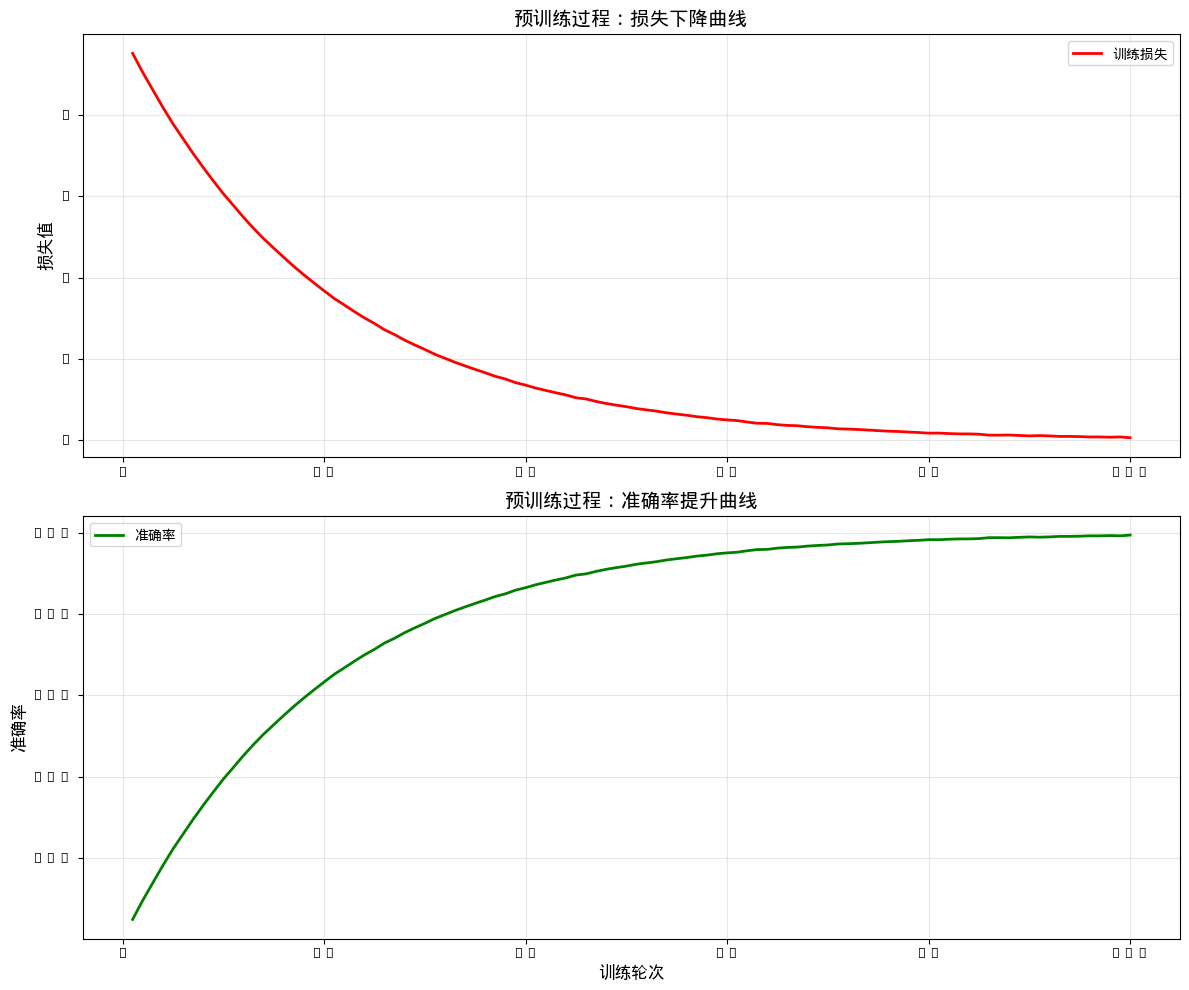

In [2]:
# 模拟预训练过程中的学习曲线
epochs = np.arange(1, 101)
loss = 10 * np.exp(-epochs/20) + 0.1 * np.random.normal(0, 0.05, len(epochs))
accuracy = 1 - loss/10

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# 损失曲线
ax1.plot(epochs, loss, 'r-', linewidth=2, label='训练损失')
ax1.set_ylabel('损失值', fontsize=12)
ax1.set_title('预训练过程：损失下降曲线', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend()

# 准确率曲线
ax2.plot(epochs, accuracy, 'g-', linewidth=2, label='准确率')
ax2.set_xlabel('训练轮次', fontsize=12)
ax2.set_ylabel('准确率', fontsize=12)
ax2.set_title('预训练过程：准确率提升曲线', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## 📈 Scaling Laws：性能与规模的数学关系

大模型最神奇的现象之一！⚡
• 不是线性关系：模型翻倍，性能不止翻倍
• 有临界点：达到某个规模后能力突然爆发
• 数据和参数都要合适：缺一不可
• GPT-3的经验：1750亿参数 + 45TB文本 = 强大的语言理解能力

/tmp/ipykernel_285828/3661317880.py:32: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/3661317880.py:32: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/3661317880.py:32: UserWarning: Glyph 49 (1) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/3661317880.py:32: UserWarning: Glyph 66 (B) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/3661317880.py:32: UserWarning: Glyph 48 (0) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/3661317880.py:32: UserWarning: Glyph 55 (7) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/3661317880.py:32: UserWarning: Glyph 53 (5) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/3661317880.py:32: UserWarning: Glyph 50 (2) missing from font(s) Droid Sa

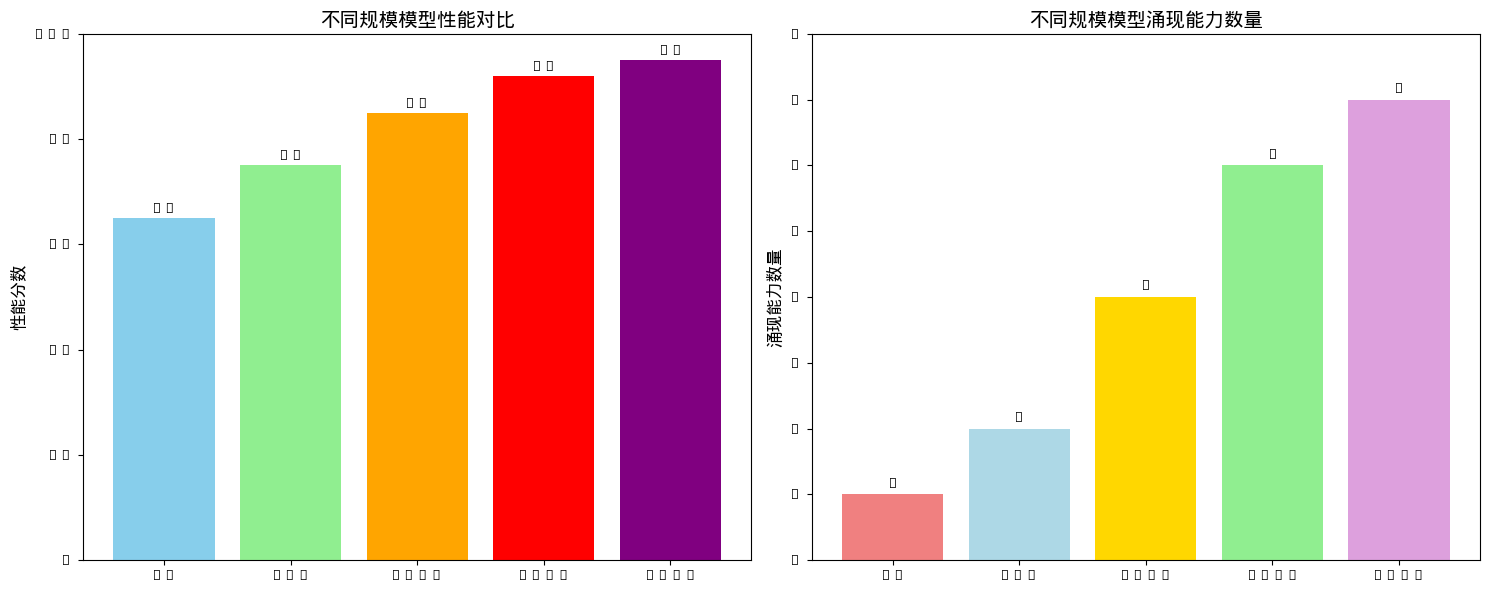

In [3]:
# 可视化不同规模模型的性能对比
model_sizes = ['1B', '10B', '100B', '175B', '500B']
performance_scores = [65, 75, 85, 92, 95]  # 模拟性能分数
emergent_abilities = [1, 2, 4, 6, 7]  # 涌现能力数量

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 性能对比
bars1 = ax1.bar(model_sizes, performance_scores, color=['skyblue', 'lightgreen', 'orange', 'red', 'purple'])
ax1.set_title('不同规模模型性能对比', fontsize=14)
ax1.set_ylabel('性能分数', fontsize=12)
ax1.set_ylim(0, 100)

# 添加数值标签
for bar, score in zip(bars1, performance_scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{score}', ha='center', va='bottom')

# 涌现能力对比
bars2 = ax2.bar(model_sizes, emergent_abilities, color=['lightcoral', 'lightblue', 'gold', 'lightgreen', 'plum'])
ax2.set_title('不同规模模型涌现能力数量', fontsize=14)
ax2.set_ylabel('涌现能力数量', fontsize=12)
ax2.set_ylim(0, 8)

# 添加数值标签
for bar, ability in zip(bars2, emergent_abilities):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{ability}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## ✨ 涌现能力：大模型的"魔法时刻"

这是最酷的部分！小模型完全不会，大模型突然就会了～ 🎭
• **数学推理**：GPT-3不会，GPT-4突然就会做复杂数学题
• **代码生成**：小模型只能写简单代码，大模型能写完整程序
• **多语言翻译**：不只是字典翻译，而是真正的理解转换
• **逻辑推理**：能理解复杂因果关系，不是简单的模式匹配

💡 业务的启示：AI应用需要足够大的模型才能实现真正的智能，不是简单的参数堆砌！

/tmp/ipykernel_285828/3069636010.py:36: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/3069636010.py:36: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
Font 'default' does not have a glyph for '1' [U+31], substituting with a dummy symbol.
Font 'default' does not have a glyph for '0' [U+30], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for 'x' [U+78], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '1' [U+31], substituting with a dummy symbol.
Font 'default' does not have a glyph for '1' [U+31], substituting with a dummy symbol.
Font 'default' does not have a glyph for '0' [U+30], substituting with a dummy symbol.
Font 'default' does not have a

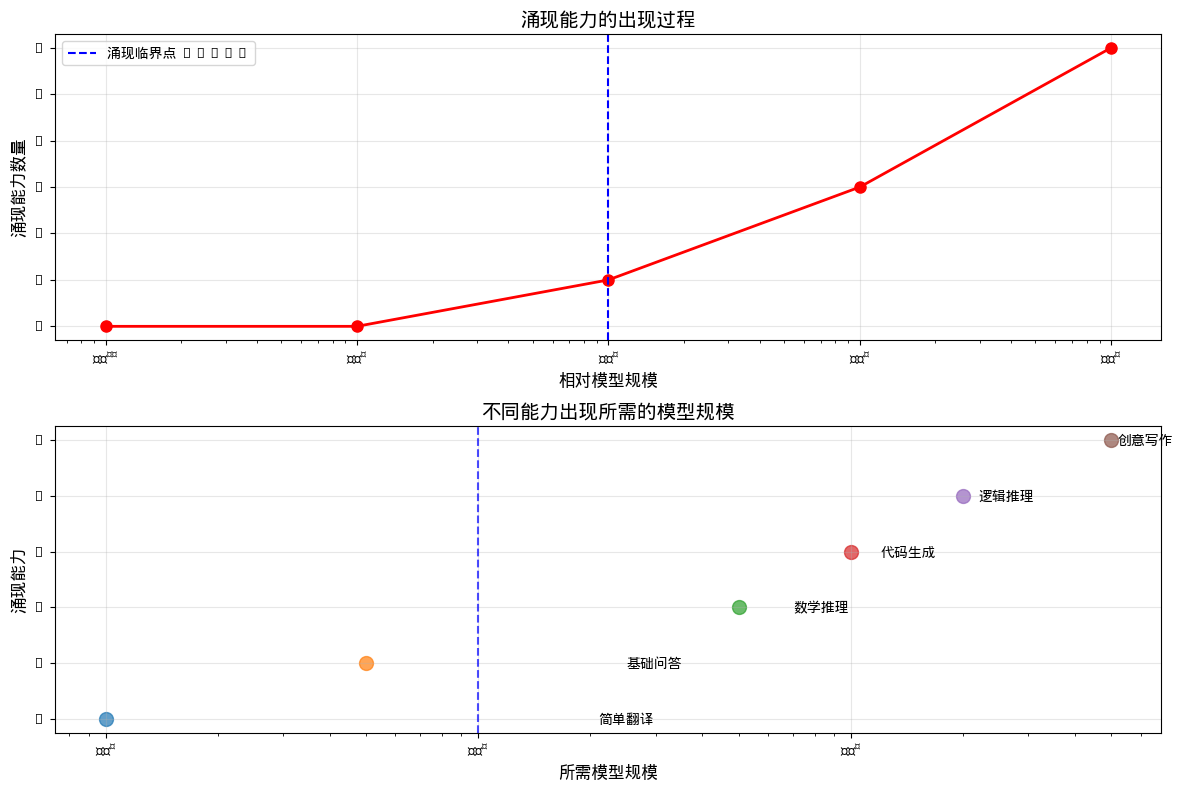

In [4]:
# 模拟涌现能力的出现过程
model_sizes = np.array([0.1, 1, 10, 100, 1000])  # 相对规模
abilities = np.array([0, 0, 1, 3, 6])  # 涌现能力数量
threshold = 10  # 涌现出现的临界点

plt.figure(figsize=(12, 8))

# 绘制涌现能力曲线
plt.subplot(2, 1, 1)
plt.plot(model_sizes, abilities, 'ro-', linewidth=2, markersize=8)
plt.axvline(x=threshold, color='blue', linestyle='--', label=f'涌现临界点 ({threshold}x)')
plt.xlabel('相对模型规模', fontsize=12)
plt.ylabel('涌现能力数量', fontsize=12)
plt.title('涌现能力的出现过程', fontsize=14)
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.legend()

# 绘制具体涌现能力示例
plt.subplot(2, 1, 2)
emergent_examples = ['简单翻译', '基础问答', '数学推理', '代码生成', '逻辑推理', '创意写作']
appear_sizes = [1, 5, 50, 100, 200, 500]  # 出现所需的相对规模

for i, (ability, size) in enumerate(zip(emergent_examples, appear_sizes)):
    if size <= 1000:  # 只显示已出现的能力
        plt.scatter(size, i, s=100, alpha=0.7)
        plt.text(size + 20, i, ability, fontsize=10, va='center')

plt.axvline(x=threshold, color='blue', linestyle='--', alpha=0.7)
plt.xlabel('所需模型规模', fontsize=12)
plt.ylabel('涌现能力', fontsize=12)
plt.title('不同能力出现所需的模型规模', fontsize=14)
plt.xscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📦 预训练数据的奥秘

数据质量决定一切！📚
• **规模要大**：至少TB级别文本
• **质量要高**：去除低质量、重复、有害内容
• **多样性要好**：书籍、网页、论文、对话等各种文体
• **时效性重要**：包含最新知识，避免完全过时

🤔 糖水店的启示：好的食材才能做出美味的糖水，AI也是一样！

/tmp/ipykernel_285828/4056128530.py:25: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/4056128530.py:25: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/4056128530.py:25: UserWarning: Glyph 51 (3) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/4056128530.py:25: UserWarning: Glyph 53 (5) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/4056128530.py:25: UserWarning: Glyph 46 (.) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/4056128530.py:25: UserWarning: Glyph 48 (0) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/4056128530.py:25: UserWarning: Glyph 37 (%) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_285828/4056128530.py:25: UserWarning: Glyph 50 (2) missing from font(s) Droid Sa

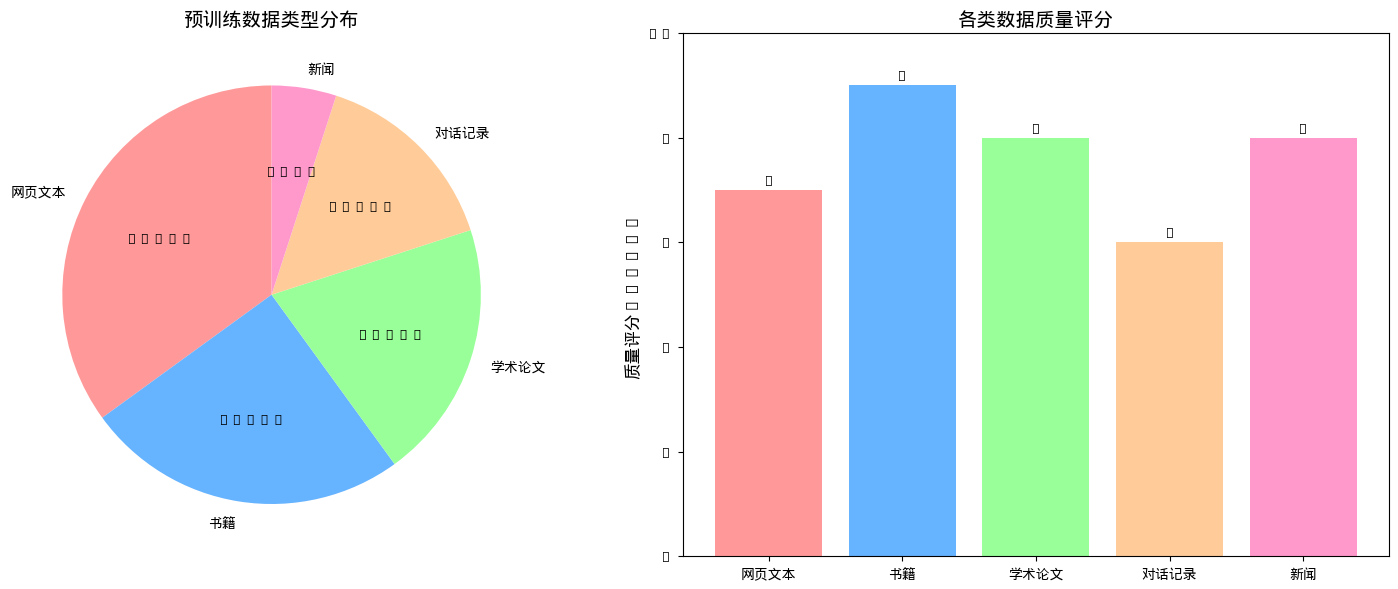

In [5]:
# 模拟预训练数据分布
data_types = ['网页文本', '书籍', '学术论文', '对话记录', '新闻']
percentages = [35, 25, 20, 15, 5]  # 模拟占比
quality_scores = [7, 9, 8, 6, 8]  # 模拟质量评分(1-10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 数据类型分布饼图
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
ax1.pie(percentages, labels=data_types, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('预训练数据类型分布', fontsize=14)

# 数据质量对比
bars = ax2.bar(data_types, quality_scores, color=colors)
ax2.set_title('各类数据质量评分', fontsize=14)
ax2.set_ylabel('质量评分(1-10)', fontsize=12)
ax2.set_ylim(0, 10)

# 添加数值标签
for bar, score in zip(bars, quality_scores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{score}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 🎓 练习题与思考题

### 📝 思考题（5分钟）

1. **为什么模型越大能力越强？**
   *提示：想想大脑神经元数量的关系～*

2. **涌现能力有什么特别之处？**
   *提示：与小模型的根本区别在哪里？*

3. **预训练数据需要具备什么特征？**
   *提示：从质量和多样性两方面思考～*

### 📊 测试题（15分钟）

❶ GPT-3的参数量大约是多少？
   A. 1.5亿  B. 1750亿  C. 5000亿  D. 1万亿

❷ 下列哪项不是大模型的涌现能力？
   A. 翻译  B. 数学推理  C. 代码生成  D. 逻辑推理

❸ Scaling Laws告诉我们：
   A. 数据越多越好  B. 参数越多越好  
   C. 数据和参数都要适度增加  D. 只需关注数据质量

❹ 涌现能力的定义是：
   A. 模型天生就会的能力  B. 模型规模达到阈值后突然出现的能力
   C. 通过调参获得的能力  D. 预训练数据中明确标注的能力

❺ 预训练阶段的主要目标是：
   A. 让模型学会特定任务  B. 让模型掌握基础语言能力
   C. 让模型记住所有知识  D. 让模型学会与人对话

## 🎬 推荐学习资源

### 📹 视频课程
• **GPT-3原理详解**：深入理解预训练过程
  https://www.bilibili.com/video/BV1w4411L7t3

• **大模型训练实战**： hands-on 预训练实践
  https://www.bilibili.com/video/BV1qP4y1D7nA

### 📖 阅读材料
• **Scaling Laws for Neural Language Models**：GPT-3论文的核心发现
  https://arxiv.org/abs/2001.08361

• **Emergent Abilities in Large Language Models**：涌现能力的详细分析
  https://arxiv.org/abs/2206.07682

### 💡 代码实践
• **Hugging Face Transformers预训练教程**：动手实践预训练
  https://huggingface.co/learn/nlp-course/chapter7/1

## 🔗 代码实践准备

今天的理论为明天做准备！明天我们将开始SFT的代码实战，理解如何在预训练的基础上进行有监督微调。

**建议预习内容：**
• 了解Hugging Face Transformers的基本使用
• 准备好Python环境和必要的库（torch, transformers等）
• 思考：为什么在预训练后还需要微调？

🚀 明见！